In [1]:
# Task 3: Predicting Insurance Claims Amount using Linear Regression

Insurance dataset created successfully!
Dataset Matrix Shape: (200, 4)
--------------------------------------------------


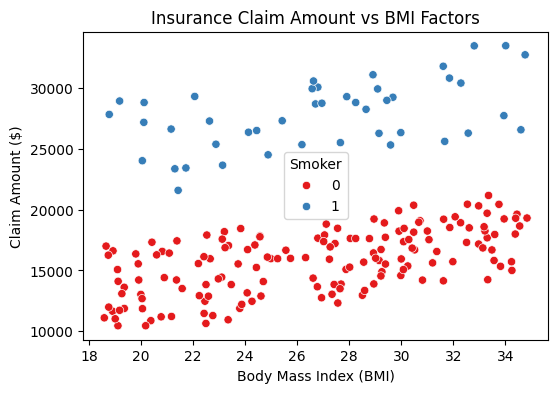

,Age,BMI,Smoker,Claim_Amount
0,56,22.654408,0,15965.115464
1,46,26.704600,1,28713.218016
2,32,23.464492,0,13838.860883
3,60,23.199868,0,18194.643309
4,25,19.108635,0,10450.816543


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Generating local insurance data to avoid any downloading errors
np.random.seed(42)
total_customers = 200

# Generating realistic features for medical insurance
customer_age = np.random.randint(18, 65, size=total_customers)
customer_bmi = np.random.uniform(18.5, 35.0, size=total_customers)
smoker_status = np.random.choice([1, 0], size=total_customers, p=[0.2, 0.8])

# Calculating claim amount based on these factors
base_claim = (customer_age * 150) + (customer_bmi * 320) + (smoker_status * 12000) + np.random.normal(1000, 500, size=total_customers)

df = pd.DataFrame({
    'Age': customer_age,
    'BMI': customer_bmi,
    'Smoker': smoker_status,
    'Claim_Amount': base_claim
})

print("Insurance dataset created successfully!")
print("Dataset Matrix Shape:", df.shape)
print("-" * 50)

# Scatter plot checking how BMI affects the Insurance Claim Amount
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='BMI', y='Claim_Amount', hue='Smoker', palette='Set1')
plt.title('Insurance Claim Amount vs BMI Factors')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Claim Amount ($)')
plt.show()

df.head()

In [3]:
# Separating inputs (X) and target claim money (y)
X = df[['Age', 'BMI', 'Smoker']]
y = df['Claim_Amount']

# Split data using standard 80% train and 20% test partition
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training Linear Regression
insurance_model = LinearRegression()
insurance_model.fit(X_train, y_train)

# Testing predictions
predicted_claims = insurance_model.predict(X_test)

# Calculating standard regression metrics
mse_score = mean_squared_error(y_test, predicted_claims)
r2_score_val = r2_score(y_test, predicted_claims)

print(f"Mean Squared Error (MSE): {mse_score:.2f}")
print(f"R-squared Score (Model Evaluation): {r2_score_val * 100:.2f}%")
print("-" * 50)
print("Model Coefficients for features (Age, BMI, Smoker):", insurance_model.coef_)

Mean Squared Error (MSE): 296202.20
R-squared Score (Model Evaluation): 98.89%
--------------------------------------------------
Model Coefficients for features (Age, BMI, Smoker): [  149.67011272   317.3318     11927.07664952]
